In [6]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
from pathlib import Path
from datetime import date, timedelta
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import seaborn as sns

repo_root = Path(__file__).resolve().parents[2] if '__file__' in dir() else Path.cwd().parents[1]
svdir = repo_root / 'figures'
svdir.mkdir(exist_ok=True)
data_dir = repo_root / 'data' / 'observational'

plt.rc('font', size=8)
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['mathtext.default'] = 'rm'
plt.rcParams['ytick.major.pad'] = '1.5'
plt.rcParams['xtick.major.pad'] = '0.5'

BWIDTH = 0.75
XPLTL = -0.2
YPLTL = 1.02

In [7]:
COLUMN_ALIASES = {
    'NPOC': 'DOC_mM', 'TIC': 'DIC_mM',
    'NH4': 'NH4_mM', 'Cl': 'Cl_mM', 'SO4': 'SO4_mM', 'NO3': 'NO3_mM',
    'Ca': 'Ca_M', 'Fe': 'Fe_M', 'P': 'P_M', 'PO': 'P_M',
}


def make_panel(component, data, years, ax):
    sns.boxplot(
        x="trans_pos_m", y=component, data=data, ax=ax,
        width=BWIDTH, hue='year', showfliers=False, linewidth=0.8,
        palette=['dimgrey', 'gainsboro'], notch=False, showcaps=False,
        medianprops={"alpha": 0.0}, zorder=1,
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='center')
    ax.get_legend().remove()

    palette_y = ['viridis', 'rocket'] if 2017 in years else ['rocket', 'viridis']
    for year, offset, pal in zip(years, [-0.3, 0.3], palette_y):
        df = data[data['year'] == year].copy()
        df['CatPos'] = df['CatPos'] + offset
        sns.scatterplot(
            data=df, x='CatPos', y=component, hue='Date',
            palette=pal, size=4, ax=ax, edgecolor=None, legend=False,
            zorder=10,
        )
    ax.set_xlabel('Location')
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    sns.despine()


def make_colorbars(years, fig):
    palette_y = ['viridis', 'rocket'] if 2017 in years else ['rocket', 'viridis']
    positions = [[1.00, 0.55, 0.02, 0.3], [1.0, 0.15, 0.02, 0.3]]

    for year, pal, pos in zip(years, palette_y, positions):
        cbar_ax = fig.add_axes(pos)
        mind = date(int(year), 5, 25)
        maxd = date(int(year), 10, 25)
        mindf, maxdf = mind.timetuple().tm_yday, maxd.timetuple().tm_yday
        norm = matplotlib.colors.Normalize(vmin=mindf, vmax=maxdf)
        sm = cm.ScalarMappable(norm=norm, cmap=pal)
        sm.set_array(np.arange(mindf, maxdf))
        cb = fig.colorbar(sm, orientation='vertical', cax=cbar_ax, shrink=0.5)
        cb.ax.invert_yaxis()
        cb_labels = [i.get_text() for i in cb.ax.get_yticklabels()]
        startdate = date(int(year), 1, 1)
        labels = [timedelta(days=float(d) - 1.0) + startdate for d in cb_labels]
        cb.ax.set_yticklabels([d.strftime("%-d %b %y") for d in labels], size=8)
        cb.ax.set_title(str(year), size=9, rotation=0)


def load_and_process(fname, site_prefix, positions):
    data = pd.read_csv(data_dir / fname, parse_dates=['Date'])
    rename = {k: v for k, v in COLUMN_ALIASES.items() if k in data.columns and v not in data.columns}
    data.rename(columns=rename, inplace=True)
    data['trans_pos_m'] = data['Well'].map(positions)

    sub = data[data['trans_pos_m'].notna()].copy()
    sub['Ca_M'] = sub['Ca_M'] * 1e3
    sub['Fe_M'] = sub['Fe_M'] * 1e6
    sub['P_M'] = sub['P_M'] * 1e6
    sub['SO4_mM'] = sub['SO4_mM'] * 1e3
    sub['NO3_mM'] = sub['NO3_mM'] * 1e3
    sub['NH4_mM'] = sub['NH4_mM'] * 1e3
    sub['DOC_mM'] = sub['DOC_mM'] * 1e3
    return sub


def add_panel_labels(axes_labels):
    for ax, label in axes_labels:
        ax.text(XPLTL, YPLTL, label,
                horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes, fontweight='bold', fontsize=12)


def make_figure(data, years, savename):
    """Per-site interannual comparison of porewater geochemistry.

    Panels show pH, Fe, NH4+, SO42-, DIC, and DOC at transect locations.
    Box plots summarize distributions; points are colored by sampling date.
    """
    fig, ((ax1, ax3), (ax2, ax7), (ax5, ax8)) = plt.subplots(3, 2, figsize=(6, 8))

    make_panel('pH', data, years, ax1)
    ax1.set_ylabel('pH')
    ax1.yaxis.set_major_locator(MultipleLocator(1))
    ax1.set_ylim(6.6, 8.3)

    make_panel('Fe_M', data, years, ax2)
    ax2.set_ylabel('Fe (' + r'$\mu$M)')
    ax2.set_ylim(bottom=0)

    make_panel('NH4_mM', data, years, ax3)
    ax3.set_ylabel(r'NH$_4^{+}$ ($\mu$M)')
    ax3.set_ylim(bottom=0)

    make_panel('SO4_mM', data, years, ax7)
    ax7.set_ylabel(r'SO$_4^{2-}$ ($\mu$M)')
    ax7.set_ylim(bottom=-5)

    make_panel('DIC_mM', data, years, ax5)
    ax5.set_ylabel('DIC (mM)')
    ax5.yaxis.set_major_locator(MultipleLocator(1))
    ax5.set_ylim(bottom=0)

    make_panel('DOC_mM', data, years, ax8)
    ax8.set_ylabel('DOC (' + r'$\mu$M)')
    ax8.set_ylim(bottom=0)

    add_panel_labels([
        (ax1, 'a'), (ax3, 'b'), (ax2, 'c'),
        (ax7, 'd'), (ax5, 'e'), (ax8, 'f'),
    ])

    fig.tight_layout()
    make_colorbars(years, fig)
    plt.savefig(svdir / savename, bbox_inches='tight')

/var/folders/3g/jgknmch95xsdkthq48rnkys00000gn/T/ipykernel_76535/950736043.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(data_dir / fname, parse_dates=['Date'])
/var/folders/3g/jgknmch95xsdkthq48rnkys00000gn/T/ipykernel_76535/950736043.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(data_dir / fname, parse_dates=['Date'])
/var/folders/3g/jgknmch95xsdkthq48rnkys00000gn/T/ipykernel_76535/950736043.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='center')
/var/folders/3g/jgknmch95xsdkthq48rnkys00000gn/T/i

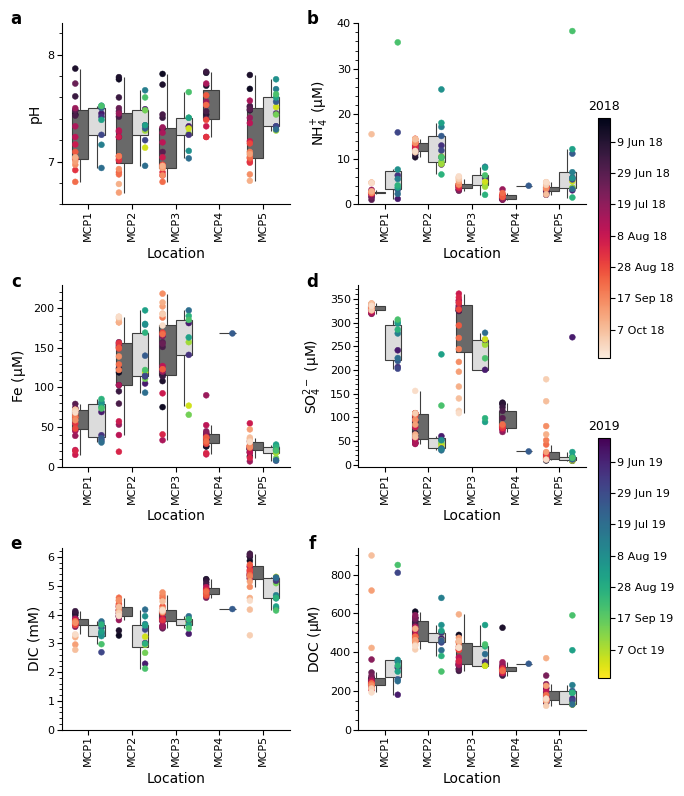

In [8]:
# MCP transect: 2018 vs 2019
mcp_positions = {
    'MCP1-1': 'MCP1', 'MCP1-2': 'MCP2', 'MCP1-3': 'MCP3',
    'MCP1-4': 'MCP4', 'MCP1-5': 'MCP5',
    'MCP1-1D': 'MCP1', 'MCP1-2D': 'MCP2', 'MCP1-3D': 'MCP3',
    'MCP1-4D': 'MCP4', 'MCP1-5D': 'MCP5',
}
mcp_catpos = {'MCP1': 0, 'MCP2': 1, 'MCP3': 2, 'MCP4': 3, 'MCP5': 4}

sub18 = load_and_process('porewater/mc_2018_porewater.csv', 'MCP', mcp_positions)
sub19 = load_and_process('porewater/mc_2019_porewater.csv', 'MCP', mcp_positions)

mcp18_19 = pd.concat([sub18, sub19], ignore_index=True)
mcp18_19['year'] = mcp18_19['Date'].dt.year
mcp18_19['CatPos'] = mcp18_19['trans_pos_m'].map(mcp_catpos)

make_figure(mcp18_19, [2018, 2019], 'mcp_transect_geochem_2018-2019.png')

/var/folders/3g/jgknmch95xsdkthq48rnkys00000gn/T/ipykernel_76535/950736043.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(data_dir / fname, parse_dates=['Date'])
/var/folders/3g/jgknmch95xsdkthq48rnkys00000gn/T/ipykernel_76535/950736043.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(data_dir / fname, parse_dates=['Date'])
/var/folders/3g/jgknmch95xsdkthq48rnkys00000gn/T/ipykernel_76535/950736043.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='center')
/var/folders/3g/jgknmch95xsdkthq48rnkys00000gn/T/i

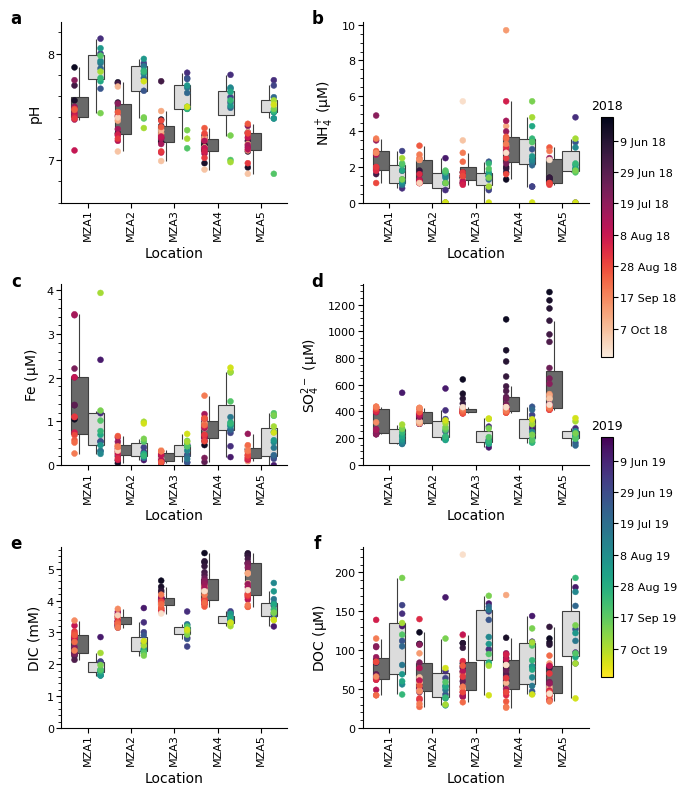

In [9]:
# MZA transect: 2018 vs 2019
mza_positions = {
    'MZT1-1-D': 'MZA1', 'MZT1-2-D': 'MZA2', 'MZT1-3-D': 'MZA3',
    'MZT1-4-D': 'MZA4', 'MZT1-5-D': 'MZA5',
    'MZT1-1D': 'MZA1', 'MZT1-2D': 'MZA2', 'MZT1-3D': 'MZA3',
    'MZT1-4D': 'MZA4', 'MZT1-5D': 'MZA5',
}
mza_catpos = {'MZA1': 0, 'MZA2': 1, 'MZA3': 2, 'MZA4': 3, 'MZA5': 4}

sub18 = load_and_process('porewater/mz_2018_porewater.csv', 'MZT1', mza_positions)
sub19 = load_and_process('porewater/mz_2019_porewater.csv', 'MZT1', mza_positions)

mza_18_19 = pd.concat([sub18, sub19], ignore_index=True)
mza_18_19['year'] = mza_18_19['Date'].dt.year
mza_18_19['CatPos'] = mza_18_19['trans_pos_m'].map(mza_catpos)

make_figure(mza_18_19, [2018, 2019], 'mza_transect_geochem_2018-2019.png')

/var/folders/3g/jgknmch95xsdkthq48rnkys00000gn/T/ipykernel_76535/2511022409.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined['location'] = combined['trans_pos_m'].map(loc_map)
/var/folders/3g/jgknmch95xsdkthq48rnkys00000gn/T/ipykernel_76535/2511022409.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='center')
/var/folders/3g/jgknmch95xsdkthq48rnkys00000gn/T/ipykernel_76535/2511022409.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalig

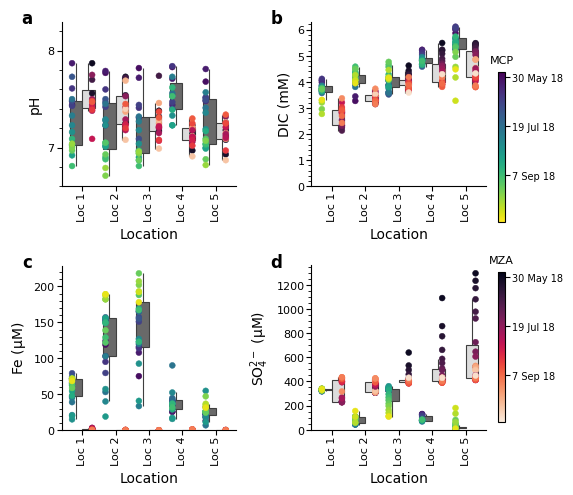

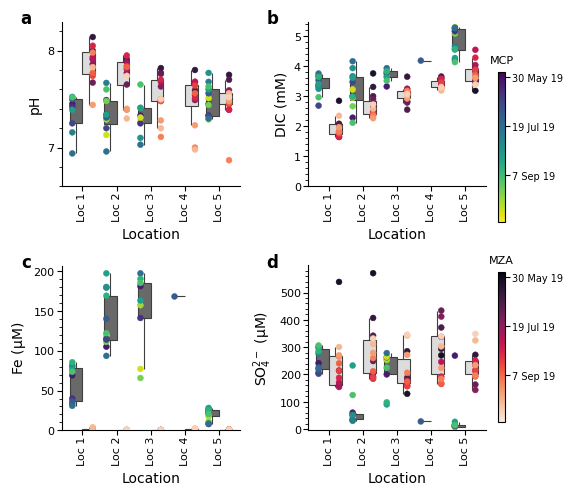

In [10]:
# Combined MCP + MZA figures, one per year
LOC_LABELS = ['Loc 1', 'Loc 2', 'Loc 3', 'Loc 4', 'Loc 5']
loc_map = {
    'MCP1': 'Loc 1', 'MCP2': 'Loc 2', 'MCP3': 'Loc 3', 'MCP4': 'Loc 4', 'MCP5': 'Loc 5',
    'MZA1': 'Loc 1', 'MZA2': 'Loc 2', 'MZA3': 'Loc 3', 'MZA4': 'Loc 4', 'MZA5': 'Loc 5',
}
combined_catpos = {f'Loc {i+1}': i for i in range(5)}


def make_combined_panel(component, data, ax):
    sns.boxplot(
        x='location', y=component, data=data, ax=ax,
        order=LOC_LABELS, width=BWIDTH, hue='site', showfliers=False,
        linewidth=0.8, palette=['dimgrey', 'gainsboro'], notch=False,
        showcaps=False, medianprops={"alpha": 0.0}, zorder=1,
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='center')
    ax.get_legend().remove()

    for site, offset, pal in [('MCP', -0.3, 'viridis'), ('MZA', 0.3, 'rocket')]:
        df = data[data['site'] == site].copy()
        df['CatPos'] = df['CatPos'] + offset
        sns.scatterplot(
            data=df, x='CatPos', y=component, hue='Date',
            palette=pal, size=4, ax=ax, edgecolor=None, legend=False,
            zorder=10,
        )
    ax.set_xlabel('Location')
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    sns.despine()


def make_combined_colorbars(year, fig):
    for pal, label, pos in [('viridis', 'MCP', [1.00, 0.55, 0.015, 0.3]),
                             ('rocket', 'MZA', [1.00, 0.15, 0.015, 0.3])]:
        cbar_ax = fig.add_axes(pos)
        mind = date(int(year), 5, 25)
        maxd = date(int(year), 10, 25)
        mindf, maxdf = mind.timetuple().tm_yday, maxd.timetuple().tm_yday
        norm = matplotlib.colors.Normalize(vmin=mindf, vmax=maxdf)
        sm = cm.ScalarMappable(norm=norm, cmap=pal)
        sm.set_array(np.arange(mindf, maxdf))
        cb = fig.colorbar(sm, orientation='vertical', cax=cbar_ax, shrink=0.5)
        cb.ax.invert_yaxis()
        cb_labels = [i.get_text() for i in cb.ax.get_yticklabels()]
        startdate = date(int(year), 1, 1)
        labels = [timedelta(days=float(d) - 1.0) + startdate for d in cb_labels]
        cb.ax.set_yticklabels([d.strftime("%-d %b %y") for d in labels], size=7)
        cb.ax.set_title(label, size=8, rotation=0)


def make_combined_figure(year, combined):
    """Cross-site comparison of porewater geochemistry at paired transect
    locations (MCP, viridis; MZA, rocket). Panels show pH, Fe, SO42-,
    and DIC. Box plots summarize distributions at each location; points
    are colored by sampling date. Locations 1-5 correspond to positions
    along the hyporheic flow path from river bank to meander interior.
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(5, 5))

    make_combined_panel('pH', combined, ax1)
    ax1.set_ylabel('pH')
    ax1.yaxis.set_major_locator(MultipleLocator(1))
    ax1.set_ylim(6.6, 8.3)

    make_combined_panel('DIC_mM', combined, ax2)
    ax2.set_ylabel('DIC (mM)')
    ax2.yaxis.set_major_locator(MultipleLocator(1))
    ax2.set_ylim(bottom=0)

    make_combined_panel('Fe_M', combined, ax3)
    ax3.set_ylabel('Fe (' + r'$\mu$M)')
    ax3.set_ylim(bottom=0)

    make_combined_panel('SO4_mM', combined, ax4)
    ax4.set_ylabel(r'SO$_4^{2-}$ ($\mu$M)')
    ax4.set_ylim(bottom=-5)

    add_panel_labels([
        (ax1, 'a'), (ax2, 'b'), (ax3, 'c'), (ax4, 'd'),
    ])

    fig.tight_layout()
    make_combined_colorbars(year, fig)
    plt.savefig(svdir / f'combined_transect_geochem_{year}.png',
                bbox_inches='tight', dpi=200)


mcp18_19['site'] = 'MCP'
mza_18_19['site'] = 'MZA'

for year in [2018, 2019]:
    combined = pd.concat([
        mcp18_19[mcp18_19['year'] == year],
        mza_18_19[mza_18_19['year'] == year],
    ], ignore_index=True)
    combined['location'] = combined['trans_pos_m'].map(loc_map)
    combined['CatPos'] = combined['location'].map(combined_catpos)
    make_combined_figure(year, combined)